# Data Visualization: Employment Type vs Job Satisfaction
**Assignment – Data Science Visualization**  
This notebook visualizes the relationship between **employment type** and **job satisfaction level** using Matplotlib, Seaborn, and Plotly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Generate & Load Dataset

In [2]:
np.random.seed(99)
n = 2400

job_types        = ['Internship', 'Part-Time', 'Full-Time', 'Freelance', 'Contract']
satisfaction_lvl = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']

type_weights = [0.10, 0.15, 0.45, 0.15, 0.15]

sat_by_type = {
    'Internship': [0.15, 0.25, 0.30, 0.20, 0.10],
    'Part-Time':  [0.10, 0.20, 0.30, 0.25, 0.15],
    'Full-Time':  [0.05, 0.10, 0.20, 0.40, 0.25],
    'Freelance':  [0.05, 0.15, 0.20, 0.35, 0.25],
    'Contract':   [0.08, 0.18, 0.25, 0.32, 0.17],
}

job_type_col     = np.random.choice(job_types, size=n, p=type_weights)
satisfaction_col = [np.random.choice(satisfaction_lvl, p=sat_by_type[jt]) for jt in job_type_col]

df = pd.DataFrame({
    'ID':               range(1, n + 1),
    'Job_Type':         job_type_col,
    'Job_Satisfaction': satisfaction_col
})

df.to_csv('job_satisfaction_dataset.csv', index=False)

df['Job_Type']         = pd.Categorical(df['Job_Type'],         categories=job_types,        ordered=True)
df['Job_Satisfaction'] = pd.Categorical(df['Job_Satisfaction'], categories=satisfaction_lvl, ordered=True)

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (2400, 3)

First 5 rows:


,ID,Job_Type,Job_Satisfaction
0,1,Full-Time,Neutral
1,2,Full-Time,Satisfied
2,3,Freelance,Dissatisfied
3,4,Internship,Neutral
4,5,Freelance,Very Satisfied


## 3. Basic Data Exploration

In [3]:
print('--- Value Counts: Job Type ---')
print(df['Job_Type'].value_counts().sort_index())
print('\n--- Value Counts: Job Satisfaction ---')
print(df['Job_Satisfaction'].value_counts().sort_index())
print('\n--- Cross Tabulation ---')
crosstab = pd.crosstab(df['Job_Type'], df['Job_Satisfaction'])
print(crosstab)

--- Value Counts: Job Type ---
Job_Type
Internship     227
Part-Time      332
Full-Time     1111
Freelance      360
Contract       370
Name: count, dtype: int64

--- Value Counts: Job Satisfaction ---
Job_Satisfaction
Very Dissatisfied    162
Dissatisfied         309
Neutral              561
Satisfied            863
Very Satisfied       505
Name: count, dtype: int64

--- Cross Tabulation ---
Job_Satisfaction  Very Dissatisfied  Dissatisfied  Neutral  Satisfied  \
Job_Type                                                                
Internship                       30            62       67         48   
Part-Time                        37            51       98         91   
Full-Time                        47            98      224        480   
Freelance                        19            37       78        129   
Contract                         29            61       94        115   

Job_Satisfaction  Very Satisfied  
Job_Type                          
Internship             

## 4. Visualization 1 – Stacked Bar Chart (Matplotlib)

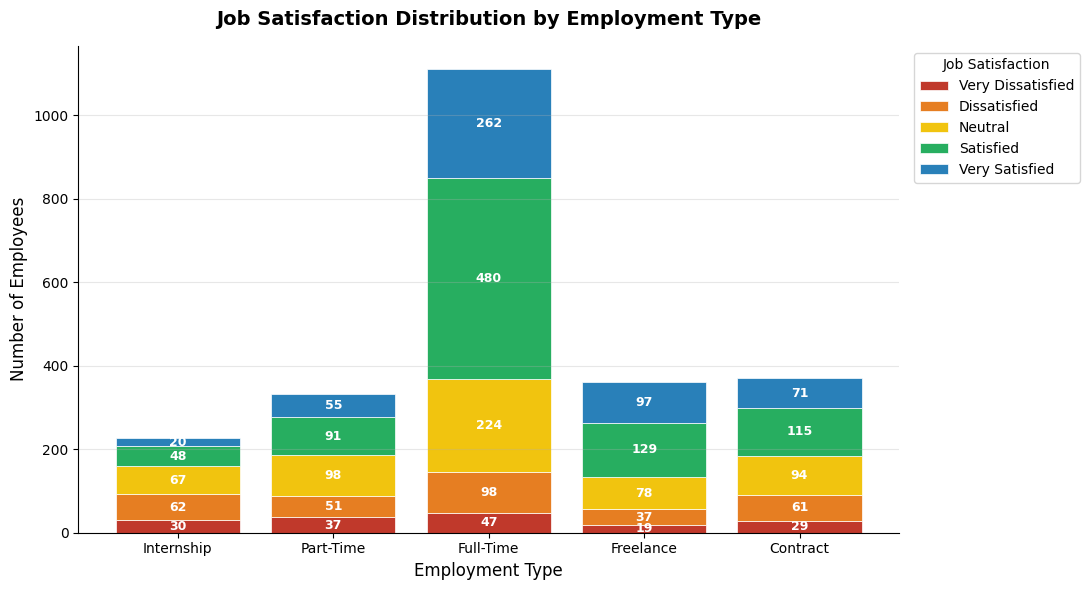

Stacked bar chart saved as stacked_bar_chart.png


In [4]:
crosstab = pd.crosstab(df['Job_Type'], df['Job_Satisfaction'])
crosstab = crosstab.reindex(columns=satisfaction_lvl)

colors   = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60', '#2980B9']

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(job_types))
for i, lvl in enumerate(satisfaction_lvl):
    bars = ax.bar(job_types, crosstab[lvl], bottom=bottom,
                  color=colors[i], label=lvl, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, crosstab[lvl]):
        if val > 15:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(val), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += crosstab[lvl].values

ax.set_title('Job Satisfaction Distribution by Employment Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Employment Type', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.legend(title='Job Satisfaction', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stacked_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stacked bar chart saved as stacked_bar_chart.png')

## 5. Visualization 2 – Grouped Bar Chart (Seaborn)

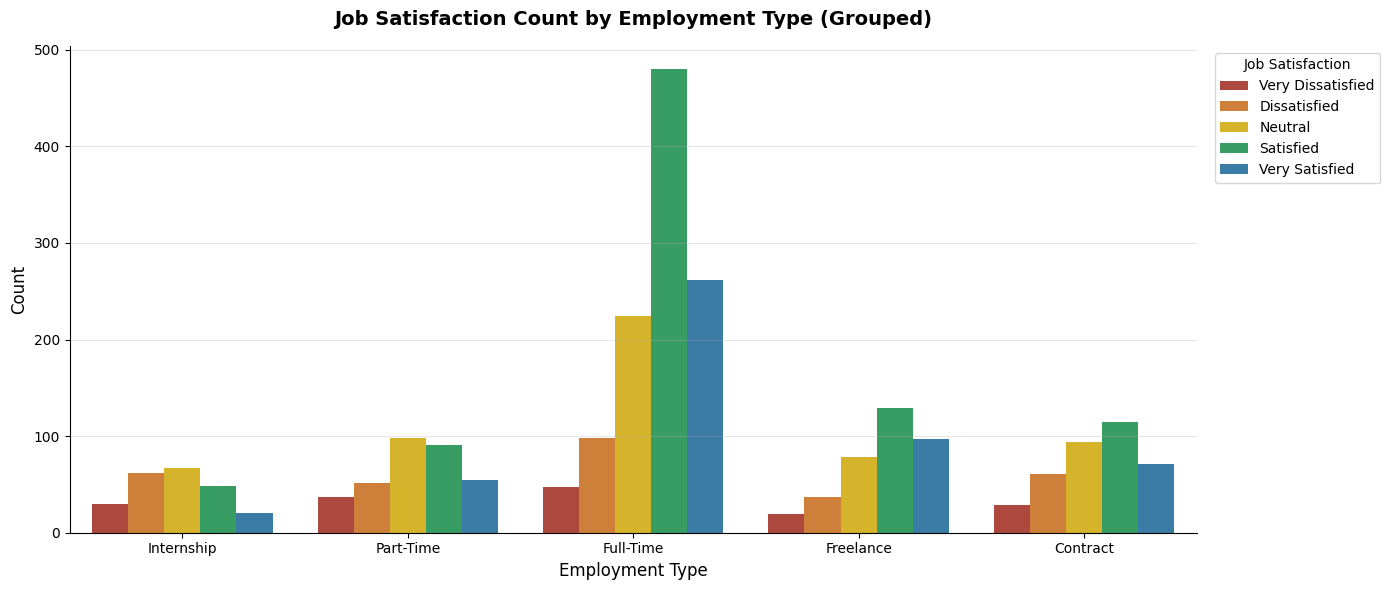

Grouped bar chart saved as grouped_bar_chart.png


In [5]:
count_df = df.groupby(['Job_Type', 'Job_Satisfaction']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data    = count_df,
    x       = 'Job_Type',
    y       = 'Count',
    hue     = 'Job_Satisfaction',
    palette = colors,
    order   = job_types,
    hue_order = satisfaction_lvl,
    ax      = ax
)

ax.set_title('Job Satisfaction Count by Employment Type (Grouped)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Employment Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Job Satisfaction', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grouped_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grouped bar chart saved as grouped_bar_chart.png')

## 6. Visualization 3 – Heatmap (Seaborn)

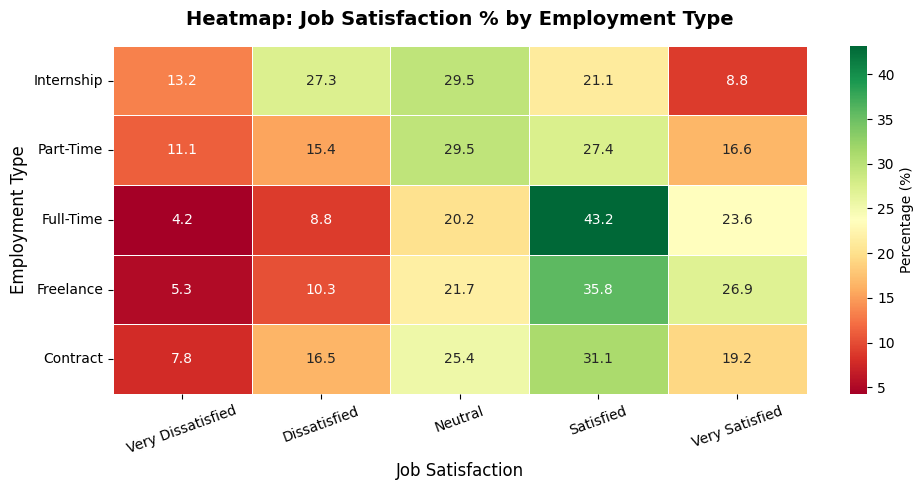

Heatmap saved as heatmap.png


In [6]:
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    crosstab_pct, annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Percentage (%)'}, ax=ax
)

ax.set_title('Heatmap: Job Satisfaction % by Employment Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Job Satisfaction', fontsize=12)
ax.set_ylabel('Employment Type', fontsize=12)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as heatmap.png')

## 7. Visualization 4 – Interactive Chart (Plotly)

In [7]:
count_df2 = df.groupby(['Job_Type', 'Job_Satisfaction']).size().reset_index(name='Count')
count_df2['Job_Type']         = pd.Categorical(count_df2['Job_Type'],         categories=job_types,        ordered=True)
count_df2['Job_Satisfaction'] = pd.Categorical(count_df2['Job_Satisfaction'], categories=satisfaction_lvl, ordered=True)
count_df2 = count_df2.sort_values(['Job_Type', 'Job_Satisfaction'])

color_map = {
    'Very Dissatisfied': '#C0392B',
    'Dissatisfied':      '#E67E22',
    'Neutral':           '#F1C40F',
    'Satisfied':         '#27AE60',
    'Very Satisfied':    '#2980B9'
}

fig2 = px.bar(
    count_df2,
    x       = 'Job_Type',
    y       = 'Count',
    color   = 'Job_Satisfaction',
    barmode = 'stack',
    color_discrete_map = color_map,
    category_orders    = {'Job_Type': job_types, 'Job_Satisfaction': satisfaction_lvl},
    title   = 'Job Satisfaction Distribution by Employment Type (Interactive)',
    labels  = {'Count': 'Number of Employees', 'Job_Type': 'Employment Type'},
    template= 'plotly_white'
)

fig2.update_layout(
    legend_title_text = 'Job Satisfaction',
    title_font_size   = 16,
    bargap            = 0.2
)

fig2.write_html('interactive_chart.html')
fig2.show()
print('Interactive chart saved as interactive_chart.html')

Interactive chart saved as interactive_chart.html


## 8. Summary & Observations

In [8]:
print('=== KEY OBSERVATIONS ===')
print()
total = len(df)
for lvl in satisfaction_lvl:
    count = (df['Job_Satisfaction'] == lvl).sum()
    print(f'{lvl:20s}: {count:4d} ({count/total*100:.1f}%)')

print()
print('--- Most common satisfaction level per employment type ---')
for jt in job_types:
    subset      = df[df['Job_Type'] == jt]
    most_common = subset['Job_Satisfaction'].value_counts().idxmax()
    print(f'{jt:12s} → {most_common}')

=== KEY OBSERVATIONS ===

Very Dissatisfied   :  162 (6.8%)
Dissatisfied        :  309 (12.9%)
Neutral             :  561 (23.4%)
Satisfied           :  863 (36.0%)
Very Satisfied      :  505 (21.0%)

--- Most common satisfaction level per employment type ---
Internship   → Neutral
Part-Time    → Neutral
Full-Time    → Satisfied
Freelance    → Satisfied
Contract     → Satisfied


#### Assignment - 2
##### Apply any ML Algorithm and get Prediction from it

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df2 = pd.read_csv('job_satisfaction_dataset.csv')

# Encode Job_Type (feature)
le_jt = LabelEncoder()
X = le_jt.fit_transform(df2['Job_Type']).reshape(-1, 1)

# Encode Job_Satisfaction (target)
le_js = LabelEncoder()
y = le_js.fit_transform(df2['Job_Satisfaction'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_js.classes_))

Accuracy: 0.28125

Classification Report:
                   precision    recall  f1-score   support

     Dissatisfied       0.00      0.00      0.00        57
          Neutral       0.26      0.64      0.37       110
        Satisfied       0.31      0.38      0.34       170
Very Dissatisfied       0.00      0.00      0.00        38
   Very Satisfied       0.00      0.00      0.00       105

         accuracy                           0.28       480
        macro avg       0.11      0.20      0.14       480
     weighted avg       0.17      0.28      0.21       480



In [10]:
# Example prediction for a specific job type
new_job_type = 'Full-Time'

new_data   = le_jt.transform([new_job_type]).reshape(-1, 1)
prediction = knn.predict(new_data)
predicted_satisfaction = le_js.inverse_transform(prediction)

print(f'Employment Type : {new_job_type}')
print(f'Predicted Job Satisfaction : {predicted_satisfaction[0]}')

Employment Type : Full-Time
Predicted Job Satisfaction : Neutral


In [12]:
job_type_input = input('Enter Employment Type (Internship / Part-Time / Full-Time / Freelance / Contract): ')

new_data   = le_jt.transform([job_type_input]).reshape(-1, 1)
prediction = knn.predict(new_data)
predicted_satisfaction = le_js.inverse_transform(prediction)

print(f'Predicted Job Satisfaction: {predicted_satisfaction[0]}')

Predicted Job Satisfaction: Satisfied
